In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

from river import tree, model_selection, utils, metrics, stream
from river.compat import convert_river_to_sklearn

import itertools

import time

In [2]:
skin_data = fetch_openml(data_id=1502, as_frame=True, parser='auto')

# Extract features and targets
X = skin_data.data
y = skin_data.target

In [3]:
X.info()

#no null values
#all features are numeric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245057 entries, 0 to 245056
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   V1      245057 non-null  int64
 1   V2      245057 non-null  int64
 2   V3      245057 non-null  int64
dtypes: int64(3)
memory usage: 5.6 MB


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=5)

X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=5)

---
# Defining what 'a pass' means here


| Model          | Natural training unit                                     | What happens     |
| -------------- | --------------------------------------------------------- | ---------------------------------------- |
| Hoeffding tree | One complete sequential exposure to all training examples | Exactly (N) calls to `learn_one`      |
| XGBoost        | One boosting round, which adds one tree                   | The tree receives (N) bootstrap draws        |
| Random Forest  | One additional independently trained tree                 | Predictions/gradients are updated and one tree is added for binary classification |


---

### Hoeffding Tree



#### Hyperparameter tuning & its results:

In [5]:
ht_param_grid = {
    'grace_period': [50, 75, 100,125,150], 
    'max_depth': [1,2,3], 
    'split_criterion': ['gini', 'info_gain', 'hellinger'],
    'leaf_prediction': ['mc', 'nb', 'nba'],
    "delta": [1e-5, 1e-7, 1e-9],
    "tau": [0.01, 0.05, 0.1]
}

def HT_hyperparam_tuning(budget, X_train, y_train, ht_param_grid=ht_param_grid):


    keys, values = zip(*ht_param_grid.items())
    combinations=[dict(zip(keys, v)) for v in itertools.product(*values)]
    
    models=[
        tree.HoeffdingTreeClassifier(**params)
        for params in combinations
    ]
    
    
    grid_search_stream = model_selection.SuccessiveHalvingClassifier(
        models=models,
        budget=budget, 
        eta=3,
        verbose=True,
        metric=metrics.ROCAUC(
            pos_val="2",
            n_thresholds=100,
        )
    )
    
    for xi_dict, yi in stream.iter_array(X_train.values, y_train.values):
        grid_search_stream.learn_one(xi_dict, yi)
    
    #getting the best model
    best_model = grid_search_stream.best_model
    print("\n" + "="*50)
    print("TUNING COMPLETE")
    print("Best Found Tree Configuration:")
    print(f"Grace Period: {best_model.grace_period}")
    print(f"Max Depth: {best_model.max_depth}")
    print(f"Split Criterion: {best_model.split_criterion}")
    print(f"Leaf Prediction Strategy: {best_model.leaf_prediction}")
    print(f"Delta:{best_model.delta}")
    print(f"Tau:{best_model.tau}")

    return best_model


In [6]:
def HT_hyperparam_val(POSITIVE_CLASS, X_val, y_val, best_model):

    validation_probabilities = []
    validation_targets = []
    
    validation_stream = stream.iter_array(
        X_val.to_numpy(),
        y_val.astype(str).to_numpy(),
    )
    
    for x_dict, y_true in validation_stream:
        probability_dict = best_model.predict_proba_one(x_dict)
    
        if POSITIVE_CLASS not in probability_dict:
            raise KeyError(
                f"Model did not return probability for class "
                f"{POSITIVE_CLASS!r}. Returned: {probability_dict}"
            )
    
        validation_probabilities.append(
            float(probability_dict[POSITIVE_CLASS])
        )
    
        validation_targets.append(
            int(y_true == POSITIVE_CLASS)
        )
    
    validation_probabilities = np.asarray(
        validation_probabilities,
        dtype=float,
    )
    
    validation_targets = np.asarray(
        validation_targets,
        dtype=int,
    )
    
    validation_auc = roc_auc_score(
        validation_targets,
        validation_probabilities,
    )
    
    print("Validation ROC-AUC:", validation_auc)
    print(
        "Probability range:",
        validation_probabilities.min(),
        validation_probabilities.max(),
    )
    print(
        "Probability standard deviation:",
        validation_probabilities.std(),
    )
    print(
        "Number of unique probabilities:",
        np.unique(
            np.round(validation_probabilities, decimals=10)
        ).size,
    )

#### Training a fresh model

In [7]:
FINAL_HT_PARAMS = {
    "grace_period": 50,
    "max_depth": 1,
    "split_criterion": "gini",
    "leaf_prediction": "mc",
    "delta": 1e-5,
    "tau": 0.01,
}

POSITIVE_CLASS = "2"

In [8]:
#preparing the train and val sets:

FEATURE_NAMES = list(X_train.columns)

X_train_array = X_train.to_numpy()
y_train_array = y_train.astype(str).to_numpy()

X_val_array = X_val.to_numpy()
y_val_array = y_val.astype(str).to_numpy()

In [9]:
#eval function
def evaluate_hoeffding_tree(
    model,
    X_eval: np.ndarray,
    y_eval: np.ndarray,
) -> dict:
    """Evaluate a River classifier using exact binary ROC-AUC."""

    probabilities = []
    binary_targets = []

    evaluation_stream = stream.iter_array(
        X_eval,
        y_eval,
        feature_names=FEATURE_NAMES,
        shuffle=False,
    )

    for row_number, (x_dict, y_true) in enumerate(
        evaluation_stream
    ):
        probability_dict = model.predict_proba_one(x_dict)

        if POSITIVE_CLASS not in probability_dict:
            raise KeyError(
                f"Positive class {POSITIVE_CLASS!r} missing "
                f"at evaluation row {row_number}. "
                f"Returned probabilities: {probability_dict}"
            )

        positive_probability = float(
            probability_dict[POSITIVE_CLASS]
        )

        probabilities.append(positive_probability)
        binary_targets.append(
            int(y_true == POSITIVE_CLASS)
        )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    binary_targets = np.asarray(
        binary_targets,
        dtype=int,
    )

    auc = roc_auc_score(
        binary_targets,
        probabilities,
    )

    brier = brier_score_loss(
        binary_targets,
        probabilities,
    )

    return {
        "roc_auc": float(auc),
        "brier_score": float(brier),
        "probability_rmse": float(np.sqrt(brier)),
        "probability_min": float(probabilities.min()),
        "probability_max": float(probabilities.max()),
        "unique_probabilities": int(
            np.unique(
                np.round(probabilities, decimals=12)
            ).size
        ),
    }

In [10]:
#shuffling dataset once:
CHECKPOINTS = list(range(1, 11))
MAX_PASSES = max(CHECKPOINTS)
ORDER_SEED = 42

rng = np.random.default_rng(ORDER_SEED)
training_order = rng.permutation(
    len(X_train_array)
)

X_train_ordered = X_train_array[training_order]
y_train_ordered = y_train_array[training_order]

In [11]:
#creating a fresh model:
ht_model = tree.HoeffdingTreeClassifier(
    **FINAL_HT_PARAMS
)

In [12]:
#running the passes:
ht_pass_results = []

cumulative_training_seconds = 0.0
cumulative_evaluation_seconds = 0.0
rows_processed = 0

for pass_number in range(1, MAX_PASSES + 1):

    # ---------------------------
    # One complete training pass
    # ---------------------------
    training_start = time.perf_counter()

    training_stream = stream.iter_array(
        X_train_ordered,
        y_train_ordered,
        feature_names=FEATURE_NAMES,
        shuffle=False,
    )

    for x_dict, y_true in training_stream:
        ht_model.learn_one(x_dict, y_true)
        rows_processed += 1

    pass_training_seconds = (
        time.perf_counter() - training_start
    )

    cumulative_training_seconds += (
        pass_training_seconds
    )

    if pass_number not in CHECKPOINTS:
        continue

    # ---------------------------
    # Validation evaluation
    # ---------------------------
    evaluation_start = time.perf_counter()

    evaluation = evaluate_hoeffding_tree(
        ht_model,
        X_val_array,
        y_val_array,
    )

    pass_evaluation_seconds = (
        time.perf_counter() - evaluation_start
    )

    cumulative_evaluation_seconds += (
        pass_evaluation_seconds
    )

    result = {
        "model": "Hoeffding Tree",
        "pass": pass_number,
        "rows_processed": rows_processed,
        "roc_auc": evaluation["roc_auc"],
        "brier_score": evaluation["brier_score"],
        "probability_rmse":
            evaluation["probability_rmse"],
        "unique_probabilities":
            evaluation["unique_probabilities"],
        "probability_min":
            evaluation["probability_min"],
        "probability_max":
            evaluation["probability_max"],
        "pass_training_seconds":
            pass_training_seconds,
        "cumulative_training_seconds":
            cumulative_training_seconds,
        "pass_evaluation_seconds":
            pass_evaluation_seconds,
        "cumulative_evaluation_seconds":
            cumulative_evaluation_seconds,
        "tree_height": getattr(
            ht_model,
            "height",
            None,
        ),
        "n_nodes": getattr(
            ht_model,
            "n_nodes",
            None,
        ),
        "n_leaves": getattr(
            ht_model,
            "n_leaves",
            None,
        ),
    }

    ht_pass_results.append(result)

    print(
        f"Pass {pass_number:>2} | "
        f"AUC={evaluation['roc_auc']:.6f} | "
        f"RMSE={evaluation['probability_rmse']:.6f} | "
        f"rows={rows_processed:,} | "
        f"train time={cumulative_training_seconds:.2f}s"
    )

Pass  1 | AUC=0.838066 | RMSE=0.318696 | rows=147,034 | train time=1.86s
Pass  2 | AUC=0.838066 | RMSE=0.318697 | rows=294,068 | train time=3.75s
Pass  3 | AUC=0.838066 | RMSE=0.318697 | rows=441,102 | train time=6.47s
Pass  4 | AUC=0.838066 | RMSE=0.318697 | rows=588,136 | train time=9.20s
Pass  5 | AUC=0.838066 | RMSE=0.318697 | rows=735,170 | train time=12.10s
Pass  6 | AUC=0.838066 | RMSE=0.318697 | rows=882,204 | train time=15.16s
Pass  7 | AUC=0.838066 | RMSE=0.318697 | rows=1,029,238 | train time=28.51s
Pass  8 | AUC=0.838066 | RMSE=0.318697 | rows=1,176,272 | train time=35.01s
Pass  9 | AUC=0.838066 | RMSE=0.318697 | rows=1,323,306 | train time=39.17s
Pass 10 | AUC=0.838066 | RMSE=0.318697 | rows=1,470,340 | train time=42.57s


In [13]:
ht_pass_results_df = pd.DataFrame(
    ht_pass_results
)

display(ht_pass_results_df)

,model,pass,rows_processed,roc_auc,brier_score,probability_rmse,unique_probabilities,probability_min,probability_max,pass_training_seconds,cumulative_training_seconds,pass_evaluation_seconds,cumulative_evaluation_seconds,tree_height,n_nodes,n_leaves
0,Hoeffding Tree,1,147034,0.838066,0.101567,0.318696,2,0.373583,0.944429,1.862672,1.862672,1.259375,1.259375,2,3,2
1,Hoeffding Tree,2,294068,0.838066,0.101568,0.318697,2,0.373434,0.944411,1.886646,3.749318,1.351995,2.611370,2,3,2
2,Hoeffding Tree,3,441102,0.838066,0.101568,0.318697,2,0.373384,0.944405,2.725231,6.474549,1.327812,3.939182,2,3,2
3,Hoeffding Tree,4,588136,0.838066,0.101568,0.318697,2,0.373359,0.944402,2.727800,9.202349,1.210791,5.149973,2,3,2
4,Hoeffding Tree,5,735170,0.838066,0.101568,0.318697,2,0.373344,0.944401,2.898980,12.101329,2.127198,7.277171,2,3,2
5,Hoeffding Tree,6,882204,0.838066,0.101568,0.318697,2,0.373334,0.944399,3.060116,15.161446,2.228494,9.505664,2,3,2
6,Hoeffding Tree,7,1029238,0.838066,0.101568,0.318697,2,0.373327,0.944399,13.345610,28.507055,4.046545,13.552210,2,3,2
7,Hoeffding Tree,8,1176272,0.838066,0.101568,0.318697,2,0.373321,0.944398,6.507486,35.014541,2.938300,16.490510,2,3,2
8,Hoeffding Tree,9,1323306,0.838066,0.101568,0.318697,2,0.373317,0.944397,4.153422,39.167963,2.776055,19.266565,2,3,2
9,Hoeffding Tree,10,1470340,0.838066,0.101568,0.318697,2,0.373314,0.944397,3.403238,42.571201,1.690349,20.956913,2,3,2


In [14]:
#saving results in a csv: 

ht_pass_results_df.to_csv(
    "Skin dataset outputs/hoeffding_tree_pass_results.csv",
    index=False,
)

In [15]:
def pass_roc_plot(df, model_name):

    plt.figure(figsize=(8, 5))

    plt.plot(
        df["pass"],
        df["roc_auc"],
        marker="o",
    )
    
    plt.xlabel("Number of complete training passes")
    plt.ylabel("Validation ROC-AUC")
    plt.title(f"{model_name}: ROC-AUC vs Training Passes")
    plt.xticks(CHECKPOINTS)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    

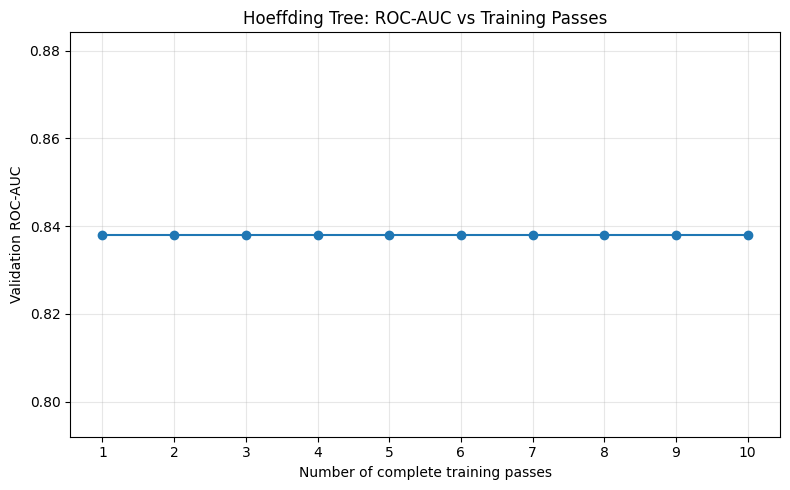

In [16]:
pass_roc_plot(df=ht_pass_results_df, model_name='Hoeffding Tree')

### Random Forest

In [17]:
#converting the label to binary for RF and XGB:

POSITIVE_LABEL = "2"

def make_binary_labels(y, positive_label="2"):
    """Convert the chosen positive label to 1 and all others to 0."""
    y_array = np.asarray(y).reshape(-1).astype(str)
    return (y_array == positive_label).astype(np.int8)


X_train_np = np.asarray(X_train, dtype=np.float32)
X_val_np = np.asarray(X_val, dtype=np.float32)

y_train_bin = make_binary_labels(
    y_train,
    positive_label=POSITIVE_LABEL,
)

y_val_bin = make_binary_labels(
    y_val,
    positive_label=POSITIVE_LABEL,
)

print("Training shape:", X_train_np.shape)
print("Validation shape:", X_val_np.shape)
print(
    "Training labels:",
    np.unique(y_train_bin, return_counts=True),
)
print(
    "Validation labels:",
    np.unique(y_val_bin, return_counts=True),
)

Training shape: (147034, 3)
Validation shape: (49012, 3)
Training labels: (array([0, 1], dtype=int8), array([ 30515, 116519]))
Validation labels: (array([0, 1], dtype=int8), array([10172, 38840]))


In [18]:
def evaluate_binary_probabilities(
    y_true,
    positive_probabilities,
):
    """Calculate exact ROC-AUC and probabilistic classification metrics."""
    y_true = np.asarray(y_true, dtype=np.int8)
    probabilities = np.asarray(
        positive_probabilities,
        dtype=np.float64,
    )

    if y_true.shape != probabilities.shape:
        raise ValueError(
            f"Shape mismatch: labels={y_true.shape}, "
            f"probabilities={probabilities.shape}"
        )

    if not np.all(np.isfinite(probabilities)):
        raise ValueError(
            "Predictions contain NaN or infinite values."
        )

    if np.any((probabilities < 0) | (probabilities > 1)):
        raise ValueError(
            "Predicted probabilities must lie between 0 and 1."
        )

    auc = roc_auc_score(
        y_true,
        probabilities,
    )

    brier = brier_score_loss(
        y_true,
        probabilities,
    )

    return {
        "roc_auc": float(auc),
        "brier_score": float(brier),
        "probability_rmse": float(np.sqrt(brier)),
        "probability_min": float(probabilities.min()),
        "probability_max": float(probabilities.max()),
        "probability_std": float(probabilities.std()),
        "unique_probabilities": int(
            np.unique(
                np.round(probabilities, decimals=12)
            ).size
        ),
    }

In [19]:
#hyperparameter tuning for RF
RF_TUNING_TREES = MAX_PASSES

rf_param_grid = {
    "criterion": [
        "gini",
        "entropy",
    ],
    "max_depth": [
        5,
        10,
        None,
    ],
    "min_samples_leaf": [
        1,
        5,
    ],
    "max_features": [
        "sqrt",
        None,
    ],
    "class_weight": [
        None,
        "balanced",
    ],
}

In [20]:
rf_configurations = list(
    ParameterGrid(rf_param_grid)
)

print(
    "Random Forest configurations:",
    len(rf_configurations),
)

Random Forest configurations: 48


In [21]:
rf_tuning_records = []

for configuration_number, params in enumerate(
    rf_configurations,
    start=1,
):
    model = RandomForestClassifier(
        n_estimators=RF_TUNING_TREES,

        # Keep this fixed for the pass definition.
        bootstrap=True,
        max_samples=None,

        random_state=5,
        n_jobs=-1,
        warm_start=False,

        **params,
    )

    training_start = time.perf_counter()

    model.fit(
        X_train_np,
        y_train_bin,
    )

    training_seconds = (
        time.perf_counter() - training_start
    )

    positive_class_column = np.flatnonzero(
        model.classes_ == 1
    )

    if positive_class_column.size != 1:
        raise RuntimeError(
            f"Could not identify positive class column. "
            f"Model classes: {model.classes_}"
        )

    probabilities = model.predict_proba(
        X_val_np
    )[:, positive_class_column[0]]

    metrics_result = evaluate_binary_probabilities(
        y_val_bin,
        probabilities,
    )

    record = {
        "configuration": configuration_number,
        "params": params.copy(),
        "training_seconds": training_seconds,
        **params,
        **metrics_result,
    }

    rf_tuning_records.append(record)

    print(
        f"RF {configuration_number:>2}/"
        f"{len(rf_configurations)} | "
        f"AUC={metrics_result['roc_auc']:.6f} | "
        f"RMSE={metrics_result['probability_rmse']:.6f} | "
        f"{training_seconds:.2f}s"
    )

RF  1/48 | AUC=0.997582 | RMSE=0.132477 | 0.50s
RF  2/48 | AUC=0.997581 | RMSE=0.132491 | 0.46s
RF  3/48 | AUC=0.993710 | RMSE=0.113160 | 0.76s
RF  4/48 | AUC=0.993700 | RMSE=0.113196 | 0.74s
RF  5/48 | AUC=0.999902 | RMSE=0.048896 | 0.45s
RF  6/48 | AUC=0.999913 | RMSE=0.047444 | 0.51s
RF  7/48 | AUC=0.999477 | RMSE=0.040357 | 0.81s
RF  8/48 | AUC=0.999492 | RMSE=0.042182 | 0.87s
RF  9/48 | AUC=0.999945 | RMSE=0.025504 | 0.53s
RF 10/48 | AUC=0.999960 | RMSE=0.030050 | 0.53s
RF 11/48 | AUC=0.999846 | RMSE=0.022108 | 1.04s
RF 12/48 | AUC=0.999865 | RMSE=0.029121 | 0.97s
RF 13/48 | AUC=0.998278 | RMSE=0.140881 | 0.44s
RF 14/48 | AUC=0.998302 | RMSE=0.140723 | 0.44s
RF 15/48 | AUC=0.993474 | RMSE=0.115142 | 0.89s
RF 16/48 | AUC=0.993469 | RMSE=0.115215 | 1.11s
RF 17/48 | AUC=0.999906 | RMSE=0.049901 | 0.94s
RF 18/48 | AUC=0.999917 | RMSE=0.048122 | 1.06s
RF 19/48 | AUC=0.999646 | RMSE=0.039387 | 1.55s
RF 20/48 | AUC=0.999669 | RMSE=0.040374 | 1.47s
RF 21/48 | AUC=0.999946 | RMSE=0.023371 

In [22]:
#saving the winnning model

rf_tuning_results_df = pd.DataFrame(
    rf_tuning_records
)

rf_tuning_results_df = (
    rf_tuning_results_df
    .sort_values(
        by=[
            "roc_auc",
            "probability_rmse",
            "training_seconds",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    rf_tuning_results_df[
        [
            "criterion",
            "max_depth",
            "min_samples_leaf",
            "max_features",
            "class_weight",
            "roc_auc",
            "probability_rmse",
            "training_seconds",
        ]
    ].head(10)
)

RF_BEST_PARAMS = (
    rf_tuning_results_df.iloc[0]["params"]
)

print("\nWinning Random Forest parameters:")
print(RF_BEST_PARAMS)


,criterion,max_depth,min_samples_leaf,max_features,class_weight,roc_auc,probability_rmse,training_seconds
0,entropy,NaN,5,sqrt,None,0.999966,0.028284,0.889504
1,gini,NaN,5,sqrt,balanced,0.999965,0.031823,0.997160
2,entropy,NaN,5,sqrt,balanced,0.999964,0.030197,0.585971
3,gini,NaN,5,sqrt,None,0.999960,0.030050,0.530805
4,entropy,NaN,1,sqrt,balanced,0.999946,0.022362,0.559778
5,gini,NaN,1,sqrt,balanced,0.999946,0.023395,1.026295
6,entropy,NaN,1,sqrt,None,0.999946,0.023371,0.881444
7,gini,NaN,1,sqrt,None,0.999945,0.025504,0.528782
8,gini,10.0,5,sqrt,balanced,0.999938,0.061105,1.107395
9,entropy,10.0,5,sqrt,None,0.999917,0.048122,1.064210



Winning Random Forest parameters:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5}


In [23]:
rf_model = RandomForestClassifier(
    n_estimators=1,
    warm_start=True,

    bootstrap=True,
    max_samples=None,

    random_state=5,
    n_jobs=-1,

    **RF_BEST_PARAMS,
)

In [24]:
rf_pass_records = []

cumulative_training_seconds = 0.0
n_training_rows = len(X_train_np)

for number_of_trees in CHECKPOINTS:
    rf_model.set_params(
        n_estimators=number_of_trees
    )

    training_start = time.perf_counter()

    rf_model.fit(
        X_train_np,
        y_train_bin,
    )

    added_tree_training_seconds = (
        time.perf_counter() - training_start
    )

    cumulative_training_seconds += (
        added_tree_training_seconds
    )

    if len(rf_model.estimators_) != number_of_trees:
        raise RuntimeError(
            f"Expected {number_of_trees} trees, "
            f"but model contains "
            f"{len(rf_model.estimators_)}."
        )

    positive_class_column = np.flatnonzero(
        rf_model.classes_ == 1
    )[0]

    probabilities = rf_model.predict_proba(
        X_val_np
    )[:, positive_class_column]

    evaluation = evaluate_binary_probabilities(
        y_val_bin,
        probabilities,
    )

    # max_samples=None means N bootstrap draws per tree.
    nominal_rows_processed = (
        number_of_trees * n_training_rows
    )

    rf_pass_records.append({
        "model": "Random Forest",
        "pass": number_of_trees,
        "native_unit": "trees",
        "rows_processed": nominal_rows_processed,
        "roc_auc": evaluation["roc_auc"],
        "brier_score": evaluation["brier_score"],
        "probability_rmse":
            evaluation["probability_rmse"],
        "unique_probabilities":
            evaluation["unique_probabilities"],
        "pass_training_seconds":
            added_tree_training_seconds,
        "cumulative_training_seconds":
            cumulative_training_seconds,
        "n_trees": len(rf_model.estimators_),
    })

    print(
        f"RF pass {number_of_trees:>2} | "
        f"AUC={evaluation['roc_auc']:.6f} | "
        f"RMSE={evaluation['probability_rmse']:.6f} | "
        f"trees={len(rf_model.estimators_):>2} | "
        f"nominal rows={nominal_rows_processed:,} | "
        f"time={cumulative_training_seconds:.2f}s"
    )

RF pass  1 | AUC=0.998681 | RMSE=0.048730 | trees= 1 | nominal rows=147,034 | time=0.18s
RF pass  2 | AUC=0.999767 | RMSE=0.037849 | trees= 2 | nominal rows=294,068 | time=0.35s
RF pass  3 | AUC=0.999808 | RMSE=0.035603 | trees= 3 | nominal rows=441,102 | time=0.57s
RF pass  4 | AUC=0.999884 | RMSE=0.032378 | trees= 4 | nominal rows=588,136 | time=0.77s
RF pass  5 | AUC=0.999924 | RMSE=0.030982 | trees= 5 | nominal rows=735,170 | time=0.94s
RF pass  6 | AUC=0.999937 | RMSE=0.031064 | trees= 6 | nominal rows=882,204 | time=1.13s
RF pass  7 | AUC=0.999966 | RMSE=0.029808 | trees= 7 | nominal rows=1,029,238 | time=1.34s
RF pass  8 | AUC=0.999966 | RMSE=0.029384 | trees= 8 | nominal rows=1,176,272 | time=1.53s
RF pass  9 | AUC=0.999965 | RMSE=0.029178 | trees= 9 | nominal rows=1,323,306 | time=1.69s
RF pass 10 | AUC=0.999966 | RMSE=0.028284 | trees=10 | nominal rows=1,470,340 | time=1.89s


In [25]:
rf_pass_results_df = pd.DataFrame(
    rf_pass_records
)

display(rf_pass_results_df)

rf_pass_results_df.to_csv(
    "Skin dataset outputs/random_forest_pass_results.csv",
    index=False,
)

,model,pass,native_unit,rows_processed,roc_auc,brier_score,probability_rmse,unique_probabilities,pass_training_seconds,cumulative_training_seconds,n_trees
0,Random Forest,1,trees,147034,0.998681,0.002375,0.048730,48,0.175745,0.175745,1
1,Random Forest,2,trees,294068,0.999767,0.001433,0.037849,138,0.173812,0.349557,2
2,Random Forest,3,trees,441102,0.999808,0.001268,0.035603,244,0.215503,0.565060,3
3,Random Forest,4,trees,588136,0.999884,0.001048,0.032378,326,0.202526,0.767586,4
4,Random Forest,5,trees,735170,0.999924,0.000960,0.030982,390,0.171676,0.939262,5
5,Random Forest,6,trees,882204,0.999937,0.000965,0.031064,495,0.189706,1.128968,6
6,Random Forest,7,trees,1029238,0.999966,0.000889,0.029808,553,0.207152,1.336120,7
7,Random Forest,8,trees,1176272,0.999966,0.000863,0.029384,614,0.196715,1.532836,8
8,Random Forest,9,trees,1323306,0.999965,0.000851,0.029178,653,0.161097,1.693933,9
9,Random Forest,10,trees,1470340,0.999966,0.000800,0.028284,691,0.193692,1.887625,10


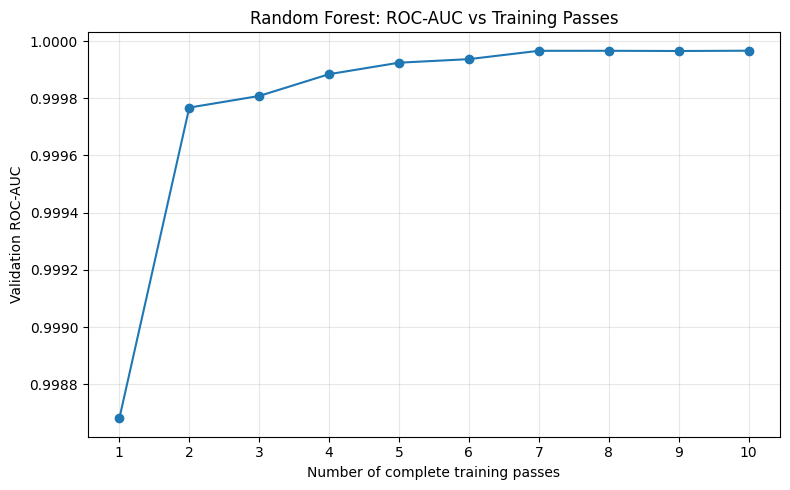

In [26]:
pass_roc_plot(df=rf_pass_results_df, model_name='Random Forest')

### XGBoost

In [27]:
#hyperparameter tuning
#keeping subsample=1 to ensure the meaning of a 'pass' is maintained
xgb_param_grid = {
    "max_depth": [
        2,
        4,
        6,
    ],
    "learning_rate": [
        0.05,
        0.1,
        0.3,
    ],
    "min_child_weight": [
        1,
        5,
    ],
    "reg_lambda": [
        1.0,
        10.0,
    ],
}

In [28]:
xgb_configurations = list(
    ParameterGrid(xgb_param_grid)
)

print(
    "XGBoost configurations:",
    len(xgb_configurations),
)

XGBoost configurations: 36


In [29]:
xgb_tuning_records = []

for configuration_number, params in enumerate(
    xgb_configurations,
    start=1,
):
    model = xgb.XGBClassifier(
        n_estimators=MAX_PASSES,

        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",

        # Keep all rows in every boosting round.
        subsample=1.0,

        # Initially keep all features available.
        colsample_bytree=1.0,

        # One tree per binary boosting round.
        num_parallel_tree=1,

        random_state=5,
        n_jobs=-1,
        verbosity=0,

        **params,
    )

    training_start = time.perf_counter()

    model.fit(
        X_train_np,
        y_train_bin,
        verbose=False,
    )

    training_seconds = (
        time.perf_counter() - training_start
    )

    positive_class_column = np.flatnonzero(
        model.classes_ == 1
    )

    if positive_class_column.size != 1:
        raise RuntimeError(
            f"Could not find XGBoost positive class. "
            f"Classes: {model.classes_}"
        )

    probabilities = model.predict_proba(
        X_val_np
    )[:, positive_class_column[0]]

    evaluation = evaluate_binary_probabilities(
        y_val_bin,
        probabilities,
    )

    xgb_tuning_records.append({
        "configuration": configuration_number,
        "params": params.copy(),
        "training_seconds": training_seconds,
        **params,
        **evaluation,
    })

    print(
        f"XGB {configuration_number:>2}/"
        f"{len(xgb_configurations)} | "
        f"AUC={evaluation['roc_auc']:.6f} | "
        f"RMSE={evaluation['probability_rmse']:.6f} | "
        f"{training_seconds:.2f}s"
    )

XGB  1/36 | AUC=0.971109 | RMSE=0.318670 | 0.16s
XGB  2/36 | AUC=0.971109 | RMSE=0.318779 | 0.15s
XGB  3/36 | AUC=0.971109 | RMSE=0.318670 | 0.16s
XGB  4/36 | AUC=0.971109 | RMSE=0.318779 | 0.16s
XGB  5/36 | AUC=0.991923 | RMSE=0.266407 | 0.18s
XGB  6/36 | AUC=0.991832 | RMSE=0.266869 | 0.17s
XGB  7/36 | AUC=0.991923 | RMSE=0.266409 | 0.17s
XGB  8/36 | AUC=0.991831 | RMSE=0.266880 | 0.17s
XGB  9/36 | AUC=0.996406 | RMSE=0.255763 | 0.18s
XGB 10/36 | AUC=0.995912 | RMSE=0.257614 | 0.18s
XGB 11/36 | AUC=0.996243 | RMSE=0.256459 | 0.18s
XGB 12/36 | AUC=0.995905 | RMSE=0.257688 | 0.17s
XGB 13/36 | AUC=0.972032 | RMSE=0.269678 | 0.15s
XGB 14/36 | AUC=0.972031 | RMSE=0.269793 | 0.15s
XGB 15/36 | AUC=0.972032 | RMSE=0.269678 | 0.17s
XGB 16/36 | AUC=0.972031 | RMSE=0.269793 | 0.16s
XGB 17/36 | AUC=0.993102 | RMSE=0.184113 | 0.16s
XGB 18/36 | AUC=0.993011 | RMSE=0.184271 | 0.18s
XGB 19/36 | AUC=0.993100 | RMSE=0.184139 | 0.17s
XGB 20/36 | AUC=0.993010 | RMSE=0.184296 | 0.17s
XGB 21/36 | AUC=0.99

In [30]:
xgb_tuning_results_df = pd.DataFrame(
    xgb_tuning_records
)

xgb_tuning_results_df = (
    xgb_tuning_results_df
    .sort_values(
        by=[
            "roc_auc",
            "probability_rmse",
            "training_seconds",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    xgb_tuning_results_df[
        [
            "max_depth",
            "learning_rate",
            "min_child_weight",
            "reg_lambda",
            "roc_auc",
            "probability_rmse",
            "training_seconds",
        ]
    ].head(10)
)

XGB_BEST_PARAMS = (
    xgb_tuning_results_df.iloc[0]["params"]
)

print("\nWinning XGBoost parameters:")
print(XGB_BEST_PARAMS)

,max_depth,learning_rate,min_child_weight,reg_lambda,roc_auc,probability_rmse,training_seconds
0,6,0.3,1,10.0,0.999229,0.073279,0.192894
1,6,0.3,5,10.0,0.999209,0.074123,0.180856
2,6,0.3,5,1.0,0.998913,0.074841,0.184874
3,6,0.3,1,1.0,0.998626,0.073616,0.201242
4,4,0.3,1,1.0,0.998039,0.092986,0.182067
5,4,0.3,5,1.0,0.998038,0.092991,0.172957
6,4,0.3,5,10.0,0.997152,0.100855,0.179609
7,4,0.3,1,10.0,0.997151,0.100830,0.173554
8,6,0.1,1,1.0,0.996723,0.169154,0.179434
9,6,0.1,5,1.0,0.996685,0.169598,0.183365



Winning XGBoost parameters:
{'learning_rate': 0.3, 'max_depth': 6, 'min_child_weight': 1, 'reg_lambda': 10.0}


In [31]:
##XGBoost’s native xgb.train function accepts a previous booster through xgb_model, allowing training to continue from an already built model
#creating XGBoost's internal data structures:
feature_names = [
    str(column)
    for column in X_train.columns
]

dtrain = xgb.DMatrix(
    X_train_np,
    label=y_train_bin,
    feature_names=feature_names,
)

dval = xgb.DMatrix(
    X_val_np,
    label=y_val_bin,
    feature_names=feature_names,
)

In [32]:
xgb_native_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",

    "max_depth":
        int(XGB_BEST_PARAMS["max_depth"]),

    # Native XGBoost commonly calls learning_rate "eta".
    "eta":
        float(XGB_BEST_PARAMS["learning_rate"]),

    "min_child_weight":
        float(XGB_BEST_PARAMS["min_child_weight"]),

    # Native parameter name corresponding to reg_lambda.
    "lambda":
        float(XGB_BEST_PARAMS["reg_lambda"]),

    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "num_parallel_tree": 1,

    "seed": 5,
    "verbosity": 0,
}

In [33]:
#adding one boosting round per loop:
xgb_pass_records = []

booster = None
cumulative_training_seconds = 0.0
n_training_rows = len(X_train_np)

for boosting_round in CHECKPOINTS:
    training_start = time.perf_counter()

    booster = xgb.train(
        params=xgb_native_params,
        dtrain=dtrain,

        # Add exactly one new boosting round.
        num_boost_round=1,

        # Continue from the existing booster.
        xgb_model=booster,

        verbose_eval=False,
    )

    round_training_seconds = (
        time.perf_counter() - training_start
    )

    cumulative_training_seconds += (
        round_training_seconds
    )

    actual_rounds = booster.num_boosted_rounds()

    if actual_rounds != boosting_round:
        raise RuntimeError(
            f"Expected {boosting_round} boosted rounds, "
            f"but booster reports {actual_rounds}."
        )

    probabilities = booster.predict(dval)

    evaluation = evaluate_binary_probabilities(
        y_val_bin,
        probabilities,
    )

    nominal_rows_processed = (
        boosting_round * n_training_rows
    )

    xgb_pass_records.append({
        "model": "XGBoost",
        "pass": boosting_round,
        "native_unit": "boosting rounds",
        "rows_processed": nominal_rows_processed,
        "roc_auc": evaluation["roc_auc"],
        "brier_score": evaluation["brier_score"],
        "probability_rmse":
            evaluation["probability_rmse"],
        "unique_probabilities":
            evaluation["unique_probabilities"],
        "pass_training_seconds":
            round_training_seconds,
        "cumulative_training_seconds":
            cumulative_training_seconds,
        "boosting_rounds": actual_rounds,
    })

    print(
        f"XGB pass {boosting_round:>2} | "
        f"AUC={evaluation['roc_auc']:.6f} | "
        f"RMSE={evaluation['probability_rmse']:.6f} | "
        f"rounds={actual_rounds:>2} | "
        f"nominal rows={nominal_rows_processed:,} | "
        f"time={cumulative_training_seconds:.2f}s"
    )

XGB pass  1 | AUC=0.994695 | RMSE=0.268743 | rounds= 1 | nominal rows=147,034 | time=0.19s
XGB pass  2 | AUC=0.994692 | RMSE=0.206954 | rounds= 2 | nominal rows=294,068 | time=0.28s
XGB pass  3 | AUC=0.996217 | RMSE=0.164411 | rounds= 3 | nominal rows=441,102 | time=0.37s
XGB pass  4 | AUC=0.996396 | RMSE=0.136861 | rounds= 4 | nominal rows=588,136 | time=0.46s
XGB pass  5 | AUC=0.996807 | RMSE=0.118151 | rounds= 5 | nominal rows=735,170 | time=0.55s
XGB pass  6 | AUC=0.997761 | RMSE=0.101249 | rounds= 6 | nominal rows=882,204 | time=0.65s
XGB pass  7 | AUC=0.998080 | RMSE=0.090380 | rounds= 7 | nominal rows=1,029,238 | time=0.75s
XGB pass  8 | AUC=0.998469 | RMSE=0.083742 | rounds= 8 | nominal rows=1,176,272 | time=0.85s
XGB pass  9 | AUC=0.999152 | RMSE=0.078392 | rounds= 9 | nominal rows=1,323,306 | time=0.96s
XGB pass 10 | AUC=0.999229 | RMSE=0.073279 | rounds=10 | nominal rows=1,470,340 | time=0.99s


In [34]:
xgb_pass_results_df = pd.DataFrame(
    xgb_pass_records
)

display(xgb_pass_results_df)

xgb_pass_results_df.to_csv(
    "Skin dataset outputs/xgboost_pass_results.csv",
    index=False,
)

,model,pass,native_unit,rows_processed,roc_auc,brier_score,probability_rmse,unique_probabilities,pass_training_seconds,cumulative_training_seconds,boosting_rounds
0,XGBoost,1,boosting rounds,147034,0.994695,0.072223,0.268743,30,0.189505,0.189505,1
1,XGBoost,2,boosting rounds,294068,0.994692,0.042830,0.206954,87,0.092605,0.282109,2
2,XGBoost,3,boosting rounds,441102,0.996217,0.027031,0.164411,156,0.089468,0.371577,3
3,XGBoost,4,boosting rounds,588136,0.996396,0.018731,0.136861,190,0.089299,0.460876,4
4,XGBoost,5,boosting rounds,735170,0.996807,0.013960,0.118151,246,0.088954,0.549830,5
5,XGBoost,6,boosting rounds,882204,0.997761,0.010251,0.101249,286,0.101273,0.651103,6
6,XGBoost,7,boosting rounds,1029238,0.998080,0.008169,0.090380,359,0.102617,0.753721,7
7,XGBoost,8,boosting rounds,1176272,0.998469,0.007013,0.083742,419,0.093127,0.846848,8
8,XGBoost,9,boosting rounds,1323306,0.999152,0.006145,0.078392,463,0.110459,0.957308,9
9,XGBoost,10,boosting rounds,1470340,0.999229,0.005370,0.073279,534,0.030268,0.987576,10


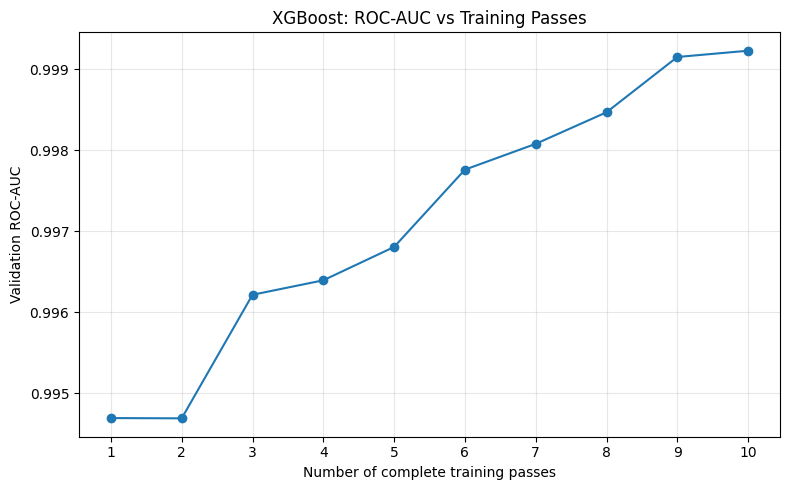

In [35]:
pass_roc_plot(df=xgb_pass_results_df, model_name='XGBoost')

### Combining comparison of all three models:

In [36]:
comparison_results_df = pd.concat(
    [
        ht_pass_results_df,
        rf_pass_results_df,
        xgb_pass_results_df,
    ],
    ignore_index=True,
    sort=False,
)

comparison_results_df.to_csv(
    "Skin dataset outputs/all_models_pass_results.csv",
    index=False,
)

display(
    comparison_results_df[
        [
            "model",
            "pass",
            "roc_auc",
            "probability_rmse",
            "cumulative_training_seconds",
        ]
    ]
)

,model,pass,roc_auc,probability_rmse,cumulative_training_seconds
0,Hoeffding Tree,1,0.838066,0.318696,1.862672
1,Hoeffding Tree,2,0.838066,0.318697,3.749318
2,Hoeffding Tree,3,0.838066,0.318697,6.474549
3,Hoeffding Tree,4,0.838066,0.318697,9.202349
4,Hoeffding Tree,5,0.838066,0.318697,12.101329
5,Hoeffding Tree,6,0.838066,0.318697,15.161446
6,Hoeffding Tree,7,0.838066,0.318697,28.507055
7,Hoeffding Tree,8,0.838066,0.318697,35.014541
8,Hoeffding Tree,9,0.838066,0.318697,39.167963
9,Hoeffding Tree,10,0.838066,0.318697,42.571201


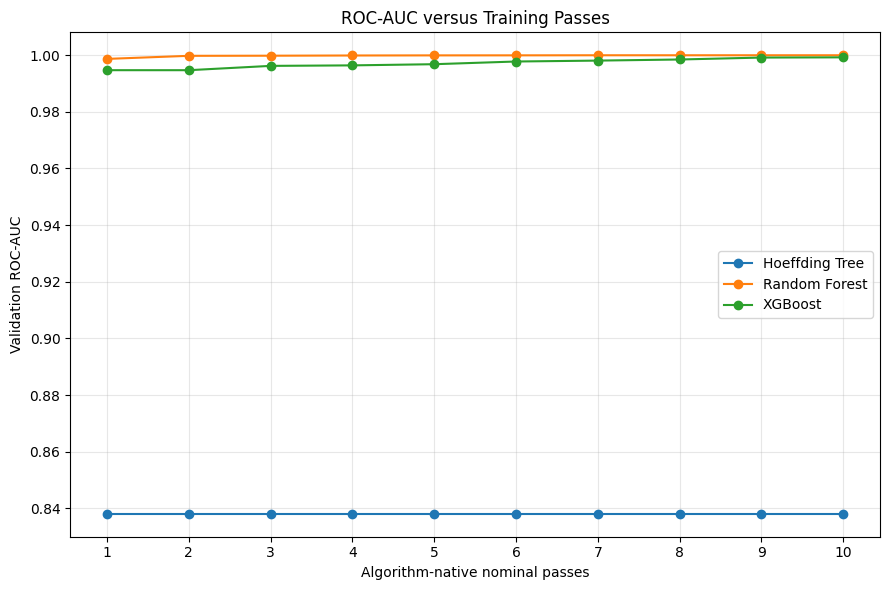

In [37]:
plt.figure(figsize=(9, 6))

for model_name, group in comparison_results_df.groupby(
    "model"
):
    ordered_group = group.sort_values("pass")

    plt.plot(
        ordered_group["pass"],
        ordered_group["roc_auc"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Algorithm-native nominal passes")
plt.ylabel("Validation ROC-AUC")
plt.title("ROC-AUC versus Training Passes")
plt.xticks(CHECKPOINTS)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

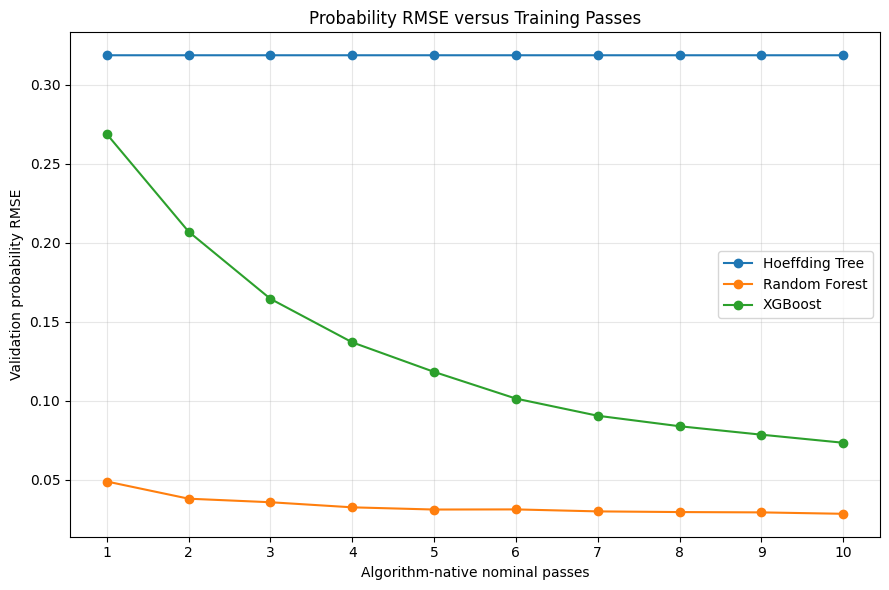

In [38]:
plt.figure(figsize=(9, 6))

for model_name, group in comparison_results_df.groupby(
    "model"
):
    ordered_group = group.sort_values("pass")

    plt.plot(
        ordered_group["pass"],
        ordered_group["probability_rmse"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Algorithm-native nominal passes")
plt.ylabel("Validation probability RMSE")
plt.title("Probability RMSE versus Training Passes")
plt.xticks(CHECKPOINTS)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

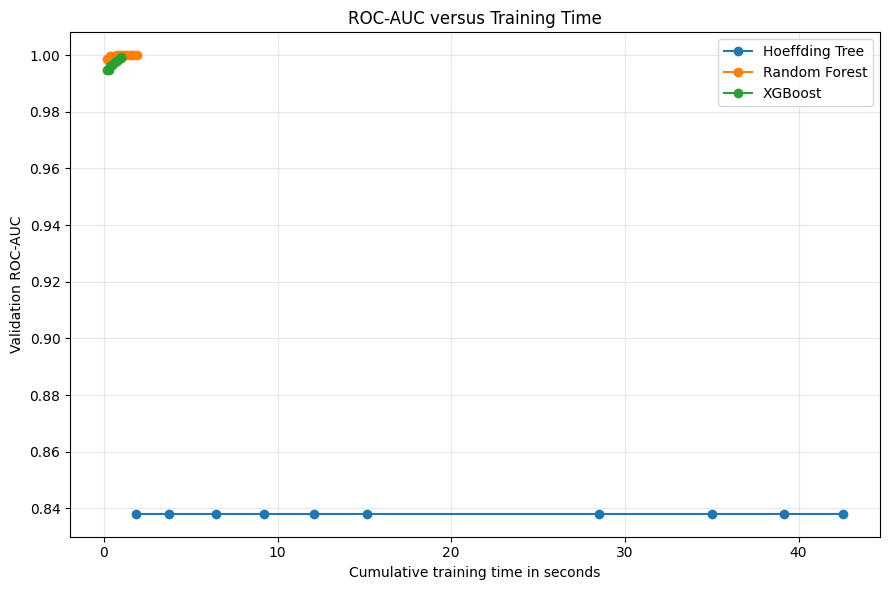

In [39]:
plt.figure(figsize=(9, 6))

for model_name, group in comparison_results_df.groupby(
    "model"
):
    ordered_group = group.sort_values(
        "cumulative_training_seconds"
    )

    plt.plot(
        ordered_group["cumulative_training_seconds"],
        ordered_group["roc_auc"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Cumulative training time in seconds")
plt.ylabel("Validation ROC-AUC")
plt.title("ROC-AUC versus Training Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()